# RUN / Train and Tune Models

### NOTES
* Set Target Mode in config.yaml
  * step: for multi-direct standard t+1, t+2, …, t+H log returns
  * rolling: for cumulative log return

* Set Save Variable if Figures and Data should be saved or not
* Set Experiment to run:
  * linreg
  * xgboost
  * cnn
  * lstm

In [1]:
SAVE = True
MODEL = "linreg" # linreg, xgboost, cnn, lstm

## Imports

In [2]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.features import create_features_and_target
from src.models.factory import experiments
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.runners import run_experiments
from src.utils import results_to_df, set_seed

## Config

* Set Save to either True or False
  * This will overwrite existing data, figures and models
* Target Mode from yaml (rolling or step)

In [3]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.n_trials
SPLITS = cfg.runtime.n_splits
TRAIN_RATIO = cfg.runtime.train_ratio
VAL_RATIO = cfg.runtime.val_ratio
GAP = cfg.runtime.gap
SUBSAMPLE_TRAIN = cfg.runtime.subsample_train
N_JOBS = cfg.runtime.n_jobs
TARGET_MODE = cfg.runtime.target_mode  # adjust target mode in config.yaml (step or rolling)
rng = set_seed(SEED)

2025-09-14 11:26:51,036 - INFO - src.utils - Global random seed set to 42


## Features
* Sentiment Notebook has to run first

In [4]:
df_price_sent = pd.read_csv(Path(cfg.data.processed_dir) / "prices_with_sentiment.csv")

In [5]:
df_full = create_features_and_target(
    df=df_price_sent,
    forecast_horizon=cfg.runtime.horizon,
    back_horizon=cfg.runtime.lag_horizon,
    training=True,
    target_mode=cfg.runtime.target_mode,  # step or rolling
    custom_horizons=cfg.runtime.horizon_list  # omit if step
)

## Choose Experiment to Run
* Set Experiment

In [6]:
EXP = [next(e for e in experiments if e.name == MODEL)]
EXP

[Experiment(name='linreg', build=<function <lambda> at 0x000001869D558860>, include_sentiment=True)]

In [7]:
results = run_experiments(
    df=df_full,
    out_dir=Path(cfg.data.processed_dir),
    experiments=EXP,
    forecast_horizon=HORIZON,
    random_state=SEED,
    n_trials=TRIALS[0] if MODEL in ["cnn", "lstm"] else TRIALS[1],
    n_splits=SPLITS,
    gap=GAP,
    subsample_train=SUBSAMPLE_TRAIN,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    n_jobs=N_JOBS,
    target_mode=TARGET_MODE,
    save=SAVE
)

2025-09-14 11:26:51,084 - INFO - src.utils - Global random seed set to 42
2025-09-14 11:26:51,105 - INFO - ModelTrainer - Initialized trainer for linreg
2025-09-14 11:27:05,679 - INFO - ModelTrainer - Initialized trainer for linreg
2025-09-14 11:27:05,739 - INFO - ModelTrainer - Evaluating model...


## Plots

In [8]:
train, val, test, forecast = time_series_split(df_full, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, horizon=HORIZON)

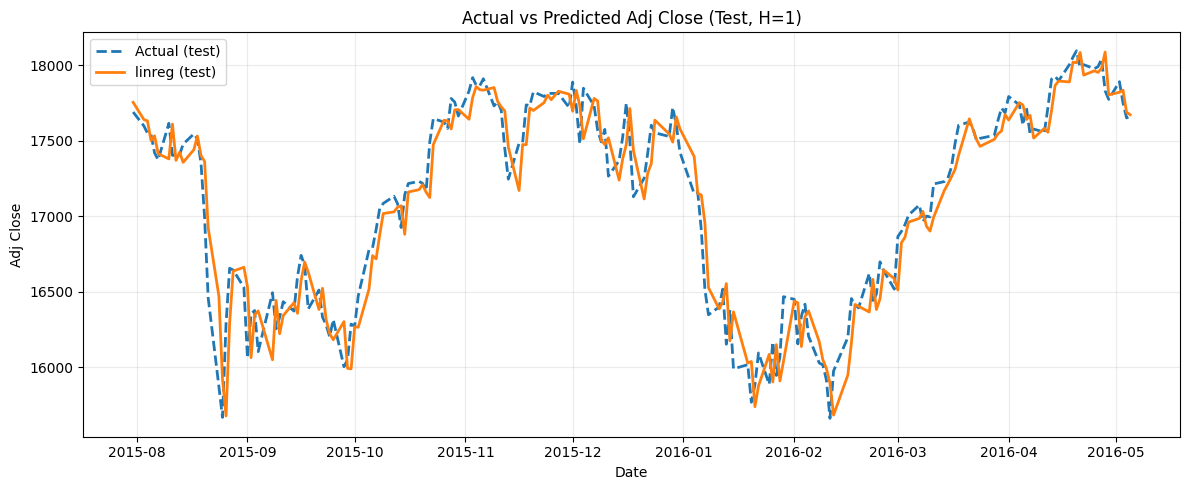

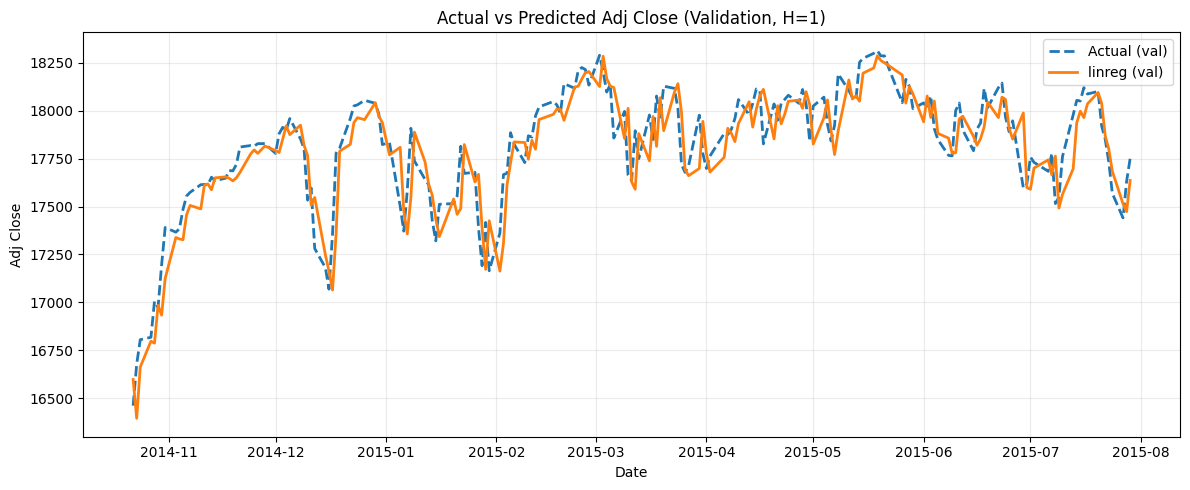

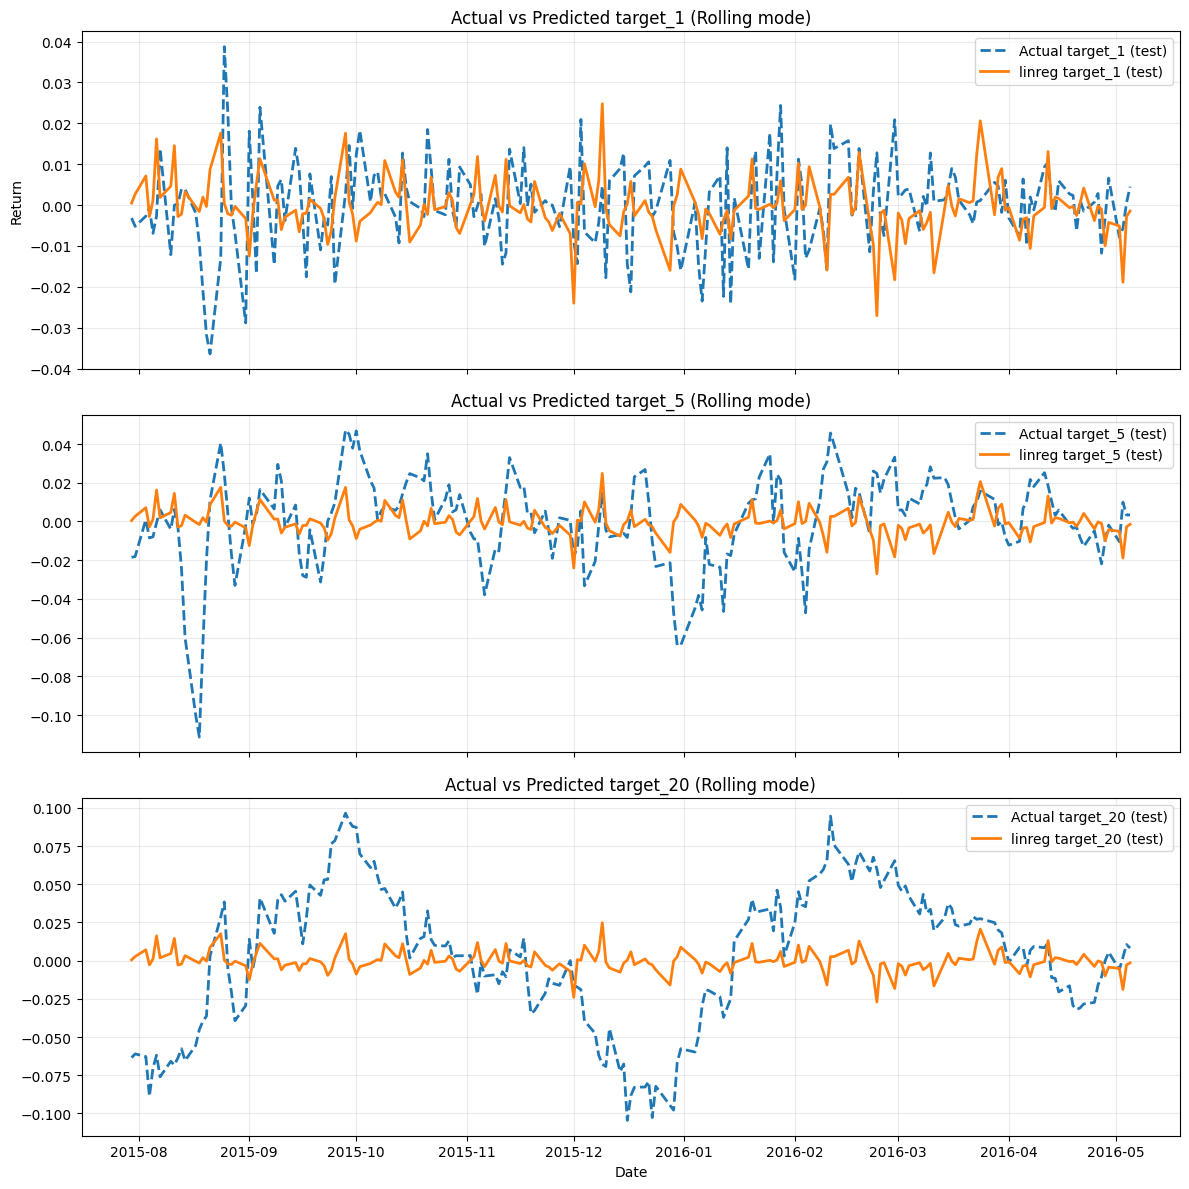

In [9]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL}_actual_vs_predicted_adj_close_test.png", save=SAVE)
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL}_actual_vs_predicted_adj_close_val.png", save=SAVE)
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL}_returns.png", phase="test", target_mode=TARGET_MODE, save=SAVE)
if TARGET_MODE == "step":
    plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL}_forecast.png", save=SAVE)
    plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL}_forecast_diagnostics.png", save=SAVE)

## Metrics

In [10]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,alpha,l1_ratio,max_iter,eta0,learning_rate,random_state
0,linreg,0.008862,0.95008,1000,0.00158,constant,42


In [11]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,linreg,0.021614,0.000968,0.031106,-0.062685,0.471601


In [12]:
metrics_summary = results_to_df(results, ["metrics", "test", "per_horizon"])
metrics_summary = metrics_summary[metrics_summary["model"] == MODEL]
metrics_summary

,model,per_horizon,mae,mse,rmse,r2,directional_accuracy
0,linreg,1,0.008243,0.000122,0.011049,-0.025271,0.528497
1,linreg,2,0.017997,0.000595,0.024400,-0.056550,0.438144
2,linreg,3,0.038600,0.002185,0.046747,-0.069590,0.448454


In [13]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()